In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

aashmadangol_plant_diseases_classification_dataset_path = kagglehub.dataset_download('aashmadangol/plant-diseases-classification-dataset')

print('Data source import complete.')


**1. IMPORTS**

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

2026-05-09 14:53:24.641266: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778338404.788017      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778338404.834722      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778338405.168719      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778338405.168761      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778338405.168764      57 computation_placer.cc:177] computation placer alr

**2. GPU CHECK**

In [ ]:
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


**3. DATASET PATH**

In [ ]:
import os

DATASET_ROOT = "/kaggle/input/datasets/aashmadangol/plant-diseases-classification-dataset"

train_dir = os.path.join(DATASET_ROOT, "train", "train")
val_dir   = os.path.join(DATASET_ROOT, "val", "val")
test_dir  = os.path.join(DATASET_ROOT, "test", "test")

print("Train dir:", train_dir)
print("Val dir:", val_dir)
print("Test dir:", test_dir)

Train dir: /kaggle/input/datasets/aashmadangol/plant-diseases-classification-dataset/train/train
Val dir: /kaggle/input/datasets/aashmadangol/plant-diseases-classification-dataset/val/val
Test dir: /kaggle/input/datasets/aashmadangol/plant-diseases-classification-dataset/test/test


**4. SAFE IMAGE COUNT**

In [ ]:
def count_images(path):
    total = 0
    class_counts = {}

    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            n = len(os.listdir(cls_path))
            class_counts[cls] = n
            total += n

    return total, class_counts

train_total, train_counts = count_images(train_dir)

print("Train images:", train_total)
print("Classes:", len(train_counts))

Train images: 67507
Classes: 38


**Visualization**

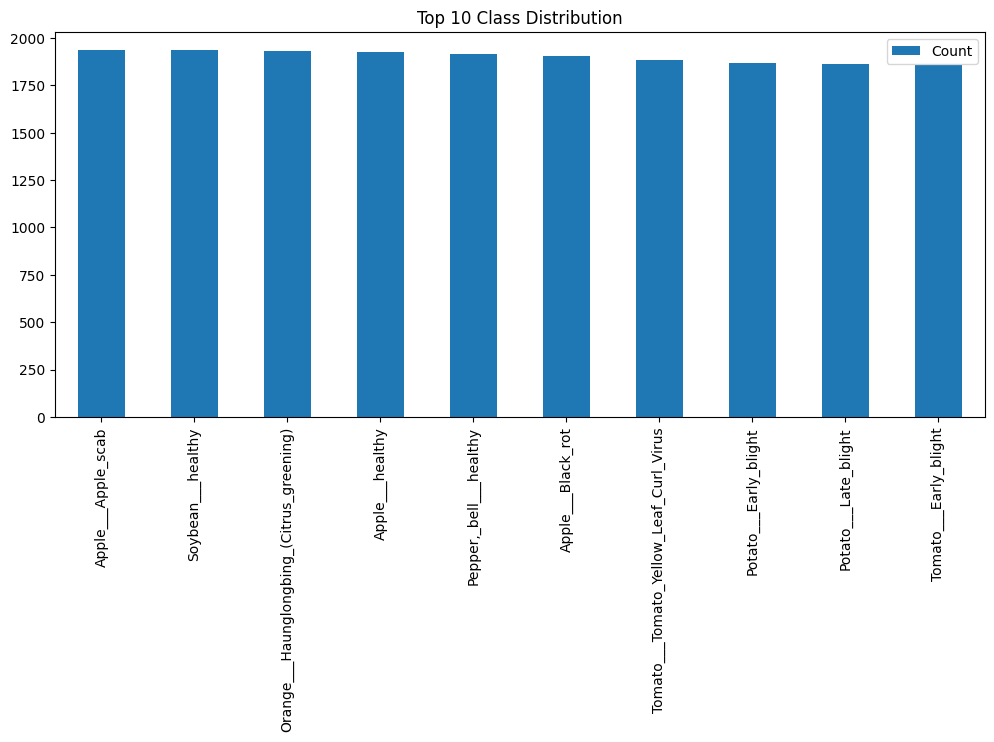

In [ ]:
df_counts = pd.DataFrame.from_dict(train_counts, orient='index', columns=['Count'])
df_counts = df_counts.sort_values(by='Count', ascending=False)

df_counts.head(10).plot(kind='bar', figsize=(12,5))
plt.title("Top 10 Class Distribution")
plt.show()

**5. SAFE CONFIG**

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 8   # 🔥 prevents RAM crash

**6. LOAD DATASET**

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)

Found 67507 files belonging to 38 classes.


I0000 00:00:1778338552.504617      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778338552.510901      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 25364 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Sep

**7. PERFORMANCE**

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds   = test_ds.prefetch(AUTOTUNE)

**8. SHOW SAMPLE IMAGES**

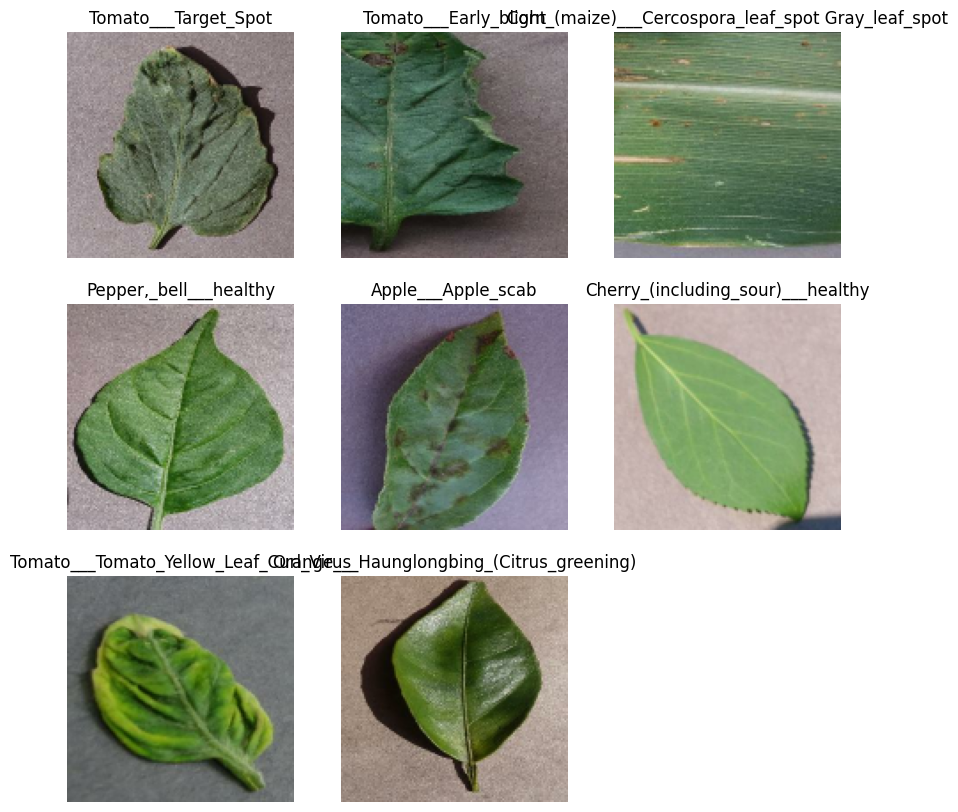

In [ ]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    n = min(9, images.shape[0])  # 🔥 prevents crash

    for i in range(n):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# **PART A — BASELINE CNN**

**9. MODEL**

In [ ]:
baseline_model = models.Sequential([
    layers.Input(shape=(128,128,3)),   # FIXED (no warning)

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

**10. COMPILE**

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**11. TRAIN**

In [ ]:
start = time.time()

history_base = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

print("Time:", time.time() - start)

Epoch 1/10


I0000 00:00:1778338906.801735     177 service.cc:152] XLA service 0x7ea3600052c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778338906.801770     177 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778338906.801773     177 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778338907.150068     177 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-09 15:01:48.476255: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 15:01:48.619402: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  13/8439 ━━━━━━━━━━━━━━━━━━━━ 1:25 10ms/step - accuracy: 0.0366 - loss: 3.6875

I0000 00:00:1778338910.261387     177 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8439/8439 ━━━━━━━━━━━━━━━━━━━━ 180s 21ms/step - accuracy: 0.5517 - loss: 1.5551 - val_accuracy: 0.8926 - val_loss: 0.3348
Epoch 2/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 68s 8ms/step - accuracy: 0.8798 - loss: 0.3751 - val_accuracy: 0.9208 - val_loss: 0.2455
Epoch 3/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 65s 8ms/step - accuracy: 0.9239 - loss: 0.2335 - val_accuracy: 0.9447 - val_loss: 0.1756
Epoch 4/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - accuracy: 0.9450 - loss: 0.1706 - val_accuracy: 0.9510 - val_loss: 0.1659
Epoch 5/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 64s 8ms/step - accuracy: 0.9559 - loss: 0.1381 - val_accuracy: 0.9536 - val_loss: 0.1706
Epoch 6/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 63s 7ms/step - accuracy: 0.9615 - loss: 0.1300 - val_accuracy: 0.9656 - val_loss: 0.1222
Epoch 7/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 63s 7ms/step - accuracy: 0.9661 - loss: 0.1200 - val_accuracy: 0.9577 - val_loss: 0.1764
Epoch 8/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 63s 7ms/step - accuracy: 0.9682 - loss: 0.1181 - v

**PART A — DEEP CNN**

In [ ]:
deep_model = models.Sequential([
    layers.Input(shape=(128,128,3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**TRAIN DEEP MODEL**

In [ ]:
history_deep = deep_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 79s 9ms/step - accuracy: 0.3254 - loss: 2.3930 - val_accuracy: 0.8154 - val_loss: 0.6055
Epoch 2/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 69s 8ms/step - accuracy: 0.7396 - loss: 0.8527 - val_accuracy: 0.8622 - val_loss: 0.4943
Epoch 3/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 69s 8ms/step - accuracy: 0.8117 - loss: 0.6094 - val_accuracy: 0.9106 - val_loss: 0.2894
Epoch 4/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 70s 8ms/step - accuracy: 0.8534 - loss: 0.4798 - val_accuracy: 0.9277 - val_loss: 0.2204
Epoch 5/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 72s 9ms/step - accuracy: 0.8756 - loss: 0.4191 - val_accuracy: 0.9461 - val_loss: 0.1788
Epoch 6/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 70s 8ms/step - accuracy: 0.8907 - loss: 0.3670 - val_accuracy: 0.9504 - val_loss: 0.1534
Epoch 7/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 71s 8ms/step - accuracy: 0.9022 - loss: 0.3363 - val_accuracy: 0.9591 - val_loss: 0.1367
Epoch 8/10
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 69s 8ms/step - accuracy: 0.9080 - loss: 0

**Training Visualization**

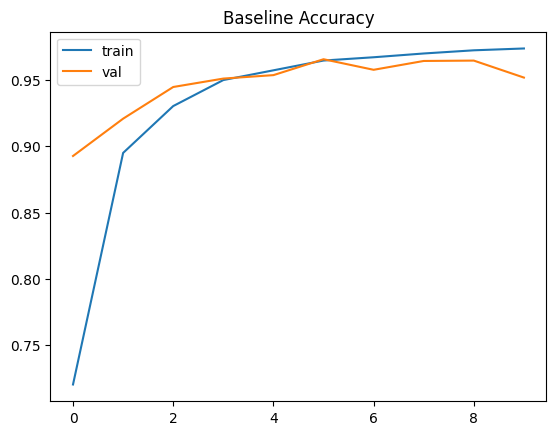

In [ ]:
plt.plot(history_base.history['accuracy'], label='train')
plt.plot(history_base.history['val_accuracy'], label='val')
plt.title("Baseline Accuracy")
plt.legend()
plt.show()

**LOSS PLOT**

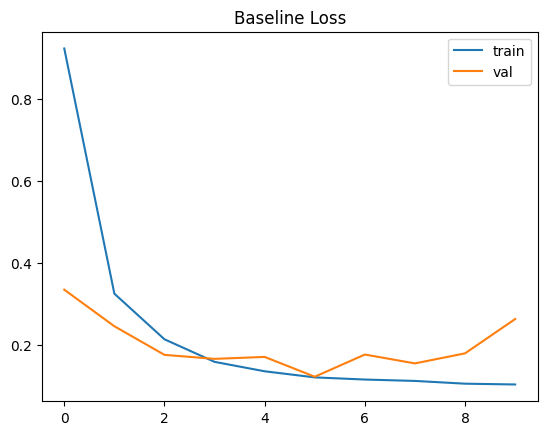

In [ ]:
plt.plot(history_base.history['loss'], label='train')
plt.plot(history_base.history['val_loss'], label='val')
plt.title("Baseline Loss")
plt.legend()
plt.show()

**PREDICTIONS**

In [ ]:
y_true_base = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_base = np.argmax(baseline_model.predict(val_ds), axis=1)

3171/3171 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step


**REPORT**

In [ ]:
print(classification_report(y_true_base, y_pred_base, target_names=class_names))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.03      0.03      0.03       727
                                 Apple___Black_rot       0.03      0.03      0.03       713
                          Apple___Cedar_apple_rust       0.03      0.03      0.03       638
                                   Apple___healthy       0.04      0.03      0.03       721
                               Blueberry___healthy       0.04      0.05      0.04       660
          Cherry_(including_sour)___Powdery_mildew       0.04      0.04      0.04       609
                 Cherry_(including_sour)___healthy       0.03      0.03      0.03       660
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.03      0.03      0.03       595
                       Corn_(maize)___Common_rust_       0.04      0.04      0.04       684
               Corn_(maize)___Northern_Leaf_Blight       0.04      0.04      0.

# **SGD vs ADAM**

In [ ]:
sgd_model = tf.keras.models.clone_model(deep_model)

sgd_model.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = sgd_model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 79s 9ms/step - accuracy: 0.1824 - loss: 2.9928 - val_accuracy: 0.3111 - val_loss: 3.0532
Epoch 2/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 67s 8ms/step - accuracy: 0.6225 - loss: 1.2565 - val_accuracy: 0.8007 - val_loss: 0.6064
Epoch 3/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 68s 8ms/step - accuracy: 0.7664 - loss: 0.7637 - val_accuracy: 0.9083 - val_loss: 0.3004
Epoch 4/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - accuracy: 0.8353 - loss: 0.5255 - val_accuracy: 0.9247 - val_loss: 0.2380
Epoch 5/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 67s 8ms/step - accuracy: 0.8770 - loss: 0.3959 - val_accuracy: 0.9546 - val_loss: 0.1477


# **ABLATION STUDY**

In [ ]:
ablation_model = models.Sequential([
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

ablation_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ablation = ablation_model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 73s 8ms/step - accuracy: 0.5811 - loss: 1.4748 - val_accuracy: 0.8790 - val_loss: 0.3933
Epoch 2/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 64s 8ms/step - accuracy: 0.8833 - loss: 0.3694 - val_accuracy: 0.9491 - val_loss: 0.1689
Epoch 3/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 64s 8ms/step - accuracy: 0.9365 - loss: 0.1975 - val_accuracy: 0.9558 - val_loss: 0.1432
Epoch 4/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 63s 8ms/step - accuracy: 0.9605 - loss: 0.1261 - val_accuracy: 0.9517 - val_loss: 0.1736
Epoch 5/5
8439/8439 ━━━━━━━━━━━━━━━━━━━━ 65s 8ms/step - accuracy: 0.9660 - loss: 0.1118 - val_accuracy: 0.9471 - val_loss: 0.2091


**PART B — TRANSFER LEARNING**

**12. MOBILE NET V2**

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

**13. DATA**

In [ ]:
train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=32
).prefetch(AUTOTUNE)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
).prefetch(AUTOTUNE)

Found 67507 files belonging to 38 classes.
Found 25364 files belonging to 38 classes.


**14. MODEL**

In [ ]:
transfer_model = models.Sequential([
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

**15. COMPILE**

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**16. TRAIN**

In [ ]:
history_transfer = transfer_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10
)

Epoch 1/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 101s 44ms/step - accuracy: 0.7378 - loss: 0.9267 - val_accuracy: 0.9568 - val_loss: 0.1432
Epoch 2/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 78s 37ms/step - accuracy: 0.9149 - loss: 0.2541 - val_accuracy: 0.9640 - val_loss: 0.1109
Epoch 3/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 78s 37ms/step - accuracy: 0.9327 - loss: 0.2000 - val_accuracy: 0.9676 - val_loss: 0.0939
Epoch 4/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 78s 37ms/step - accuracy: 0.9409 - loss: 0.1726 - val_accuracy: 0.9748 - val_loss: 0.0761
Epoch 5/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 77s 37ms/step - accuracy: 0.9473 - loss: 0.1502 - val_accuracy: 0.9752 - val_loss: 0.0735
Epoch 6/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 77s 37ms/step - accuracy: 0.9529 - loss: 0.1377 - val_accuracy: 0.9791 - val_loss: 0.0624
Epoch 7/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 75s 36ms/step - accuracy: 0.9556 - loss: 0.1299 - val_accuracy: 0.9815 - val_loss: 0.0532
Epoch 8/10
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 76s 36ms/step - accuracy: 0.9568 

**FINAL PREDICTION**

In [ ]:
import numpy as np

y_true_tl = np.concatenate([y for x, y in val_ds_tl], axis=0)
y_pred_tl = np.argmax(transfer_model.predict(val_ds_tl), axis=1)

793/793 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step


In [ ]:
from sklearn.metrics import classification_report

print("TRANSFER LEARNING CLASSIFICATION REPORT")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

TRANSFER LEARNING CLASSIFICATION REPORT
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.99      0.99       727
                                 Apple___Black_rot       1.00      1.00      1.00       713
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       638
                                   Apple___healthy       0.99      1.00      1.00       721
                               Blueberry___healthy       0.98      1.00      0.99       660
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       609
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       660
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      1.00      0.95       595
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       684
               Corn_(maize)___Northern_

**CONFUSION MATRIX**

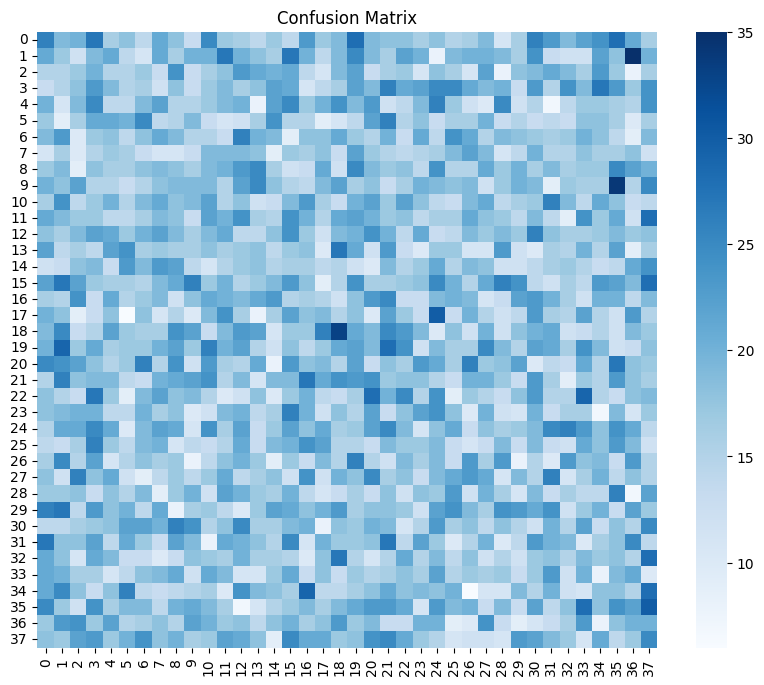

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

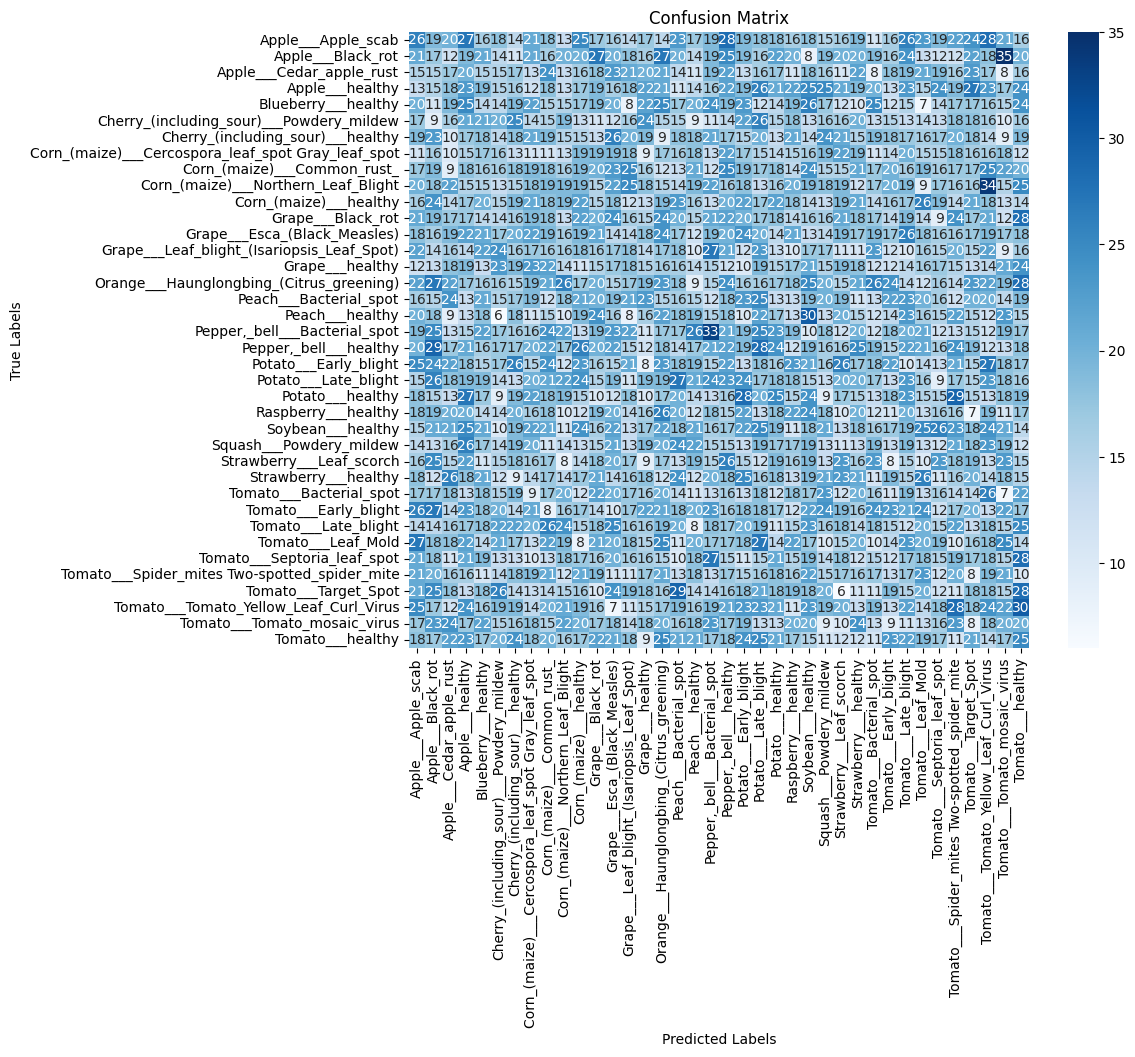

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

**FINAL MODEL COMPARISON**

In [ ]:
results = pd.DataFrame({
    "Model": ["Baseline", "Deep CNN", "Transfer Learning"],
    "Accuracy": [
        max(history_base.history['val_accuracy']),
        max(history_deep.history['val_accuracy']),
        max(history_transfer.history['val_accuracy'])
    ]
})

print(results)

               Model  Accuracy
0           Baseline  0.965621
1           Deep CNN  0.965147
2  Transfer Learning  0.984742


**VISUAL COMPARISON**

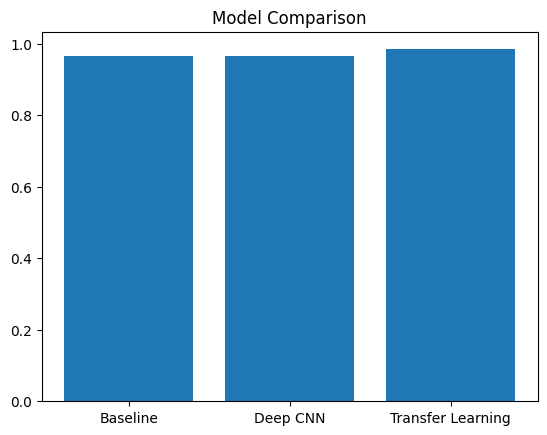

In [ ]:
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Comparison")
plt.show()

In [ ]:
test_loss, test_acc = baseline_model.evaluate(test_ds)
print("Baseline Test Accuracy:", test_acc)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8889 - loss: 0.8289
Baseline Test Accuracy: 0.8796380758285522
